**Logistic Regression - Multinomial**

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import arange
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, f1_score, roc_curve, roc_auc_score

import warnings
warnings.filterwarnings("ignore") 

In [15]:
wine_data = pd.read_csv('C:/MAFAS/APU/CT046-3-M-AML/CT046 - LABS/Python LAB MATERIALS/Lab 7 - Logistic Regression/wine.csv') 
wine_data.head()


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [16]:
wine_data.shape

(178, 14)

In [17]:
wine_data.isnull().sum()

Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64

In [18]:
wine_data.describe()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


Wine
2    71
1    59
3    48
Name: count, dtype: int64


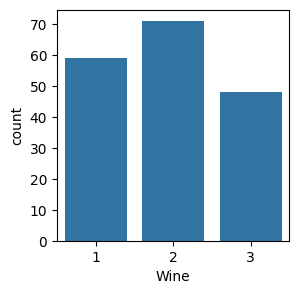

In [19]:
plt.subplots(figsize = (3,3))
sns.countplot(x = wine_data['Wine'])
print(wine_data['Wine'].value_counts())

In [20]:
x = wine_data[wine_data.columns[1:14]]
y = wine_data[wine_data.columns[0]]

In [21]:
x.columns

Index(['Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols', 'Flavanoids',
       'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue', 'OD', 'Proline'],
      dtype='object')

In [22]:
# Split the dataset into a test and training set
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

**Class Balancing**

Counter({3: 57, 2: 57, 1: 57})


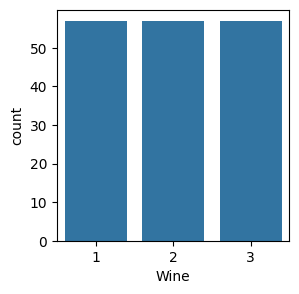

In [23]:
# %pip install imbalanced-learn
from collections import Counter
from imblearn.over_sampling import SMOTE
x_train_b, y_train_b = SMOTE().fit_resample(x_train, y_train)

plt.subplots(figsize = (3,3))
sns.countplot(x = y_train_b)
print(Counter(y_train_b))

**LR Model with Hyper-Parameter Tuning**

In [24]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 42)

In [ ]:
from sklearn.model_selection import GridSearchCV
from numpy import arange

model_LR = LogisticRegression()

parameters = dict()
parameters['penalty'] = ['l1', 'l2', 'elasticnet'] # Penalization (Regularization).
parameters['C'] = [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 7, 10] # Inverse regularization parameter - A control variable that retains strength modification of Regularization by being inversely positioned to the Lambda regulator. C = 1/λ
parameters['solver'] = ['liblinear', 'newton-cg', 'lbfgs', 'saga'] # Optimization
parameters['random_state'] = arange(1, 50, 1) 

## Building Grid Search algorithm with cross-validation and acc score.
grid_search_LR = GridSearchCV(estimator = model_LR, param_grid = parameters, scoring = 'accuracy', cv = skf)

## Lastly, finding the best parameters.
grid_search_LR.fit(x_train_b, y_train_b)

print("Best Parameters:", grid_search_LR.best_params_)
print("Best Score:", grid_search_LR.best_score_)

best_model = grid_search_LR.best_estimator_
y_pred_1 = best_model.predict(x_test)

# Get the accuracy score
lr_acc = accuracy_score(y_test, y_pred_1)
lr_pre = precision_score(y_test, y_pred_1, average = 'weighted')
lr_recall = recall_score(y_test, y_pred_1, average = 'weighted')
lr_f1 = f1_score(y_test, y_pred_1, average = 'weighted')

print("\nLR - Accuracy: {:.3f}.".format(lr_acc))
print("LR - Precision: {:.3f}.".format(lr_pre))
print("LR - Recall: {:.3f}.".format(lr_recall))
print("LR - F1 Score: {:.3f}.".format(lr_f1))
print ('\n Classification Report:\n', classification_report(y_test, y_pred_1))

Best Parameters: {'C': 1, 'penalty': 'l2', 'random_state': np.int64(0), 'solver': 'liblinear'}
Best Score: 0.9649122807017544

LR - Accuracy: 1.000.
LR - Precision: 1.000.
LR - Recall: 1.000.
LR - F1 Score: 1.000.

 Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [26]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_1)
print(cm)

[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]


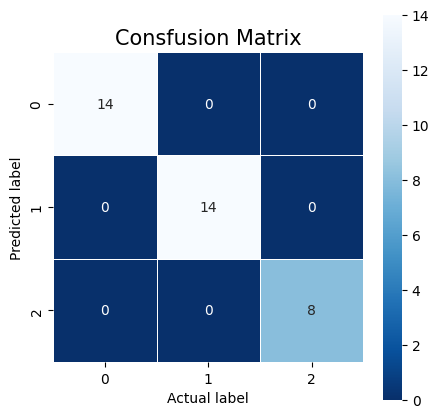

In [ ]:
plt.figure(figsize = (5,5))
sns.heatmap(cm, annot = True, linewidths = .5, square = True, cmap = 'Blues_r')
plt.xlabel('Actual label')
plt.ylabel('Predicted label')
plt.title("Consfusion Matrix", size = 15)

**Random Search**

In contrast to GridSearchCV, not all parameter values are tried out, but rather a fixed number of parameter settings is sampled from the specified distributions.

In [28]:
from sklearn.model_selection import RandomizedSearchCV

model_LR = LogisticRegression()

parameters = dict()
parameters['penalty'] = ['l1', 'l2', 'elasticnet'] # Penalization (Regularization).
parameters['C'] = [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 7, 10] # Inverse regularization parameter - A control variable that retains strength modification of Regularization by being inversely positioned to the Lambda regulator. C = 1/λ
parameters['solver'] = ['liblinear', 'newton-cg', 'lbfgs', 'saga'] # Optimization
parameters['random_state'] = arange(0, 50, 1) 


## Building Grid Search algorithm with cross-validation and acc score.
rand_search_LR = RandomizedSearchCV(model_LR, parameters, scoring = 'accuracy', cv = skf, n_iter = 10, random_state = 42)

## Lastly, finding the best parameters.
rand_search_LR.fit(x_train_b, y_train_b)
best_parameters_LR = rand_search_LR.best_params_
best_score_LR = rand_search_LR.best_score_

print("Best Parameters:", rand_search_LR.best_params_)
print("Best Score:", rand_search_LR.best_score_)

y_pred_2 = rand_search_LR.predict(x_test)

# Get the accuracy score
lr_acc_2 = accuracy_score(y_test, y_pred_2)*100
lr_pre_2 = precision_score(y_test, y_pred_2, average = 'weighted')
lr_recall_2 = recall_score(y_test, y_pred_2, average = 'weighted')
lr_f1_2 = f1_score(y_test, y_pred_2, average = 'weighted')

print("\nLR - Accuracy: {:.3f}.".format(lr_acc_2))
print("LR - Precision: {:.3f}.".format(lr_pre_2))
print("LR - Recall: {:.3f}.".format(lr_recall_2))
print("LR - F1 Score: {:.3f}.".format(lr_f1_2))
print ('\n Clasification Report:\n', classification_report(y_test,y_pred_2))

Best Parameters: {'solver': 'lbfgs', 'random_state': np.int64(6), 'penalty': 'l2', 'C': 7}
Best Score: 0.9649122807017543

LR - Accuracy: 97.222.
LR - Precision: 0.974.
LR - Recall: 0.972.
LR - F1 Score: 0.972.

 Clasification Report:
               precision    recall  f1-score   support

           1       1.00      0.93      0.96        14
           2       0.93      1.00      0.97        14
           3       1.00      1.00      1.00         8

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



In [29]:
# Confusion Matrix
cm_1 = confusion_matrix(y_test, y_pred_2)
print(cm_1)

[[13  1  0]
 [ 0 14  0]
 [ 0  0  8]]


Text(0.5, 1.0, 'Confusion Matrix')

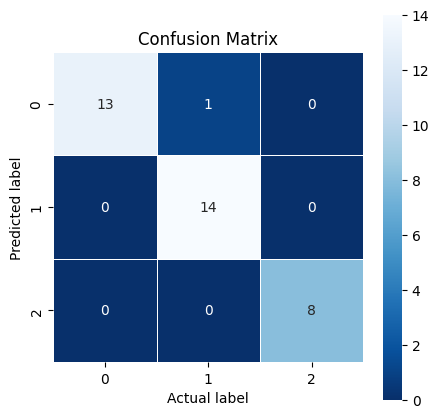

In [30]:
import seaborn as sns
plt.figure(figsize = (5,5))
sns.heatmap(cm_1, annot = True, linewidths = 0.5, square = True, cmap = 'Blues_r')
plt.xlabel('Actual label')
plt.ylabel('Predicted label')
plt.title("Confusion Matrix")